In [1]:
import utils.plots as plots
import os
import warnings

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pandas.errors import ParserWarning
import importlib

warnings.simplefilter(action='ignore', category=ParserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

import utils.data as datutils
import utils.file as futils
import utils.corrs as corutils

plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['axes.labelsize'] = 18
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"

In [2]:
mah_dict = futils.get_mah_all()

m14 = pd.read_csv('data/mag_diff_GadgetX_3k.csv')
m14.set_index('ID', inplace=True)
m14

,3d,proj_x,proj_y,proj_z
ID,,,,
1,1.009199,1.009199,1.009199,1.009199
2,0.095047,0.095047,0.095047,0.095047
3,1.098583,1.098583,1.098583,1.098583
4,1.631226,1.631226,1.631226,1.631226
5,0.068340,0.068340,0.068340,0.068340
...,...,...,...,...
320,3.705206,3.705206,3.705206,3.705206
321,1.295134,1.295134,1.295134,1.295134
322,1.950024,1.950024,1.950024,1.950024


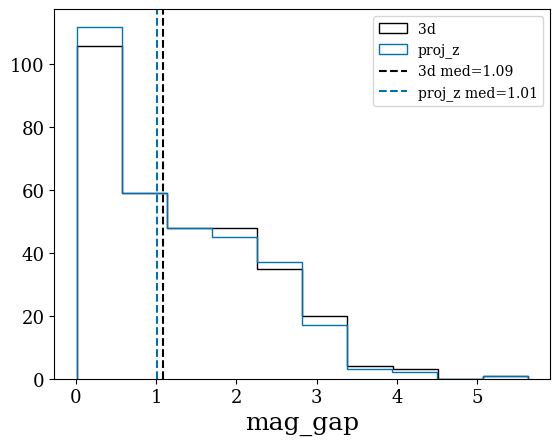

In [3]:
plt.hist(m14['3d'], label='3d', histtype='step')
# plt.hist(m14['proj_x'], label='proj_x', histtype='step')
# plt.hist(m14['proj_y'], label='proj_y', histtype='step')
plt.hist(m14['proj_z'], label='proj_z', histtype='step')
plt.axvline(x=m14['3d'].median(), color='C0', linestyle='--', label=f'3d med={m14["3d"].median():.2f}')
plt.axvline(x=m14['proj_z'].median(), color='C1', linestyle='--', label=f'proj_z med={m14["proj_z"].median():.2f}')
plt.legend()
plt.xlabel('mag_gap')
plt.show()

In [4]:
mah_gap_dict, filtered_z_list = datutils.prepare_ma_corrs(
    mah_dict, m14)
z_array = np.array(filtered_z_list)
aexp = 1/(1+z_array)

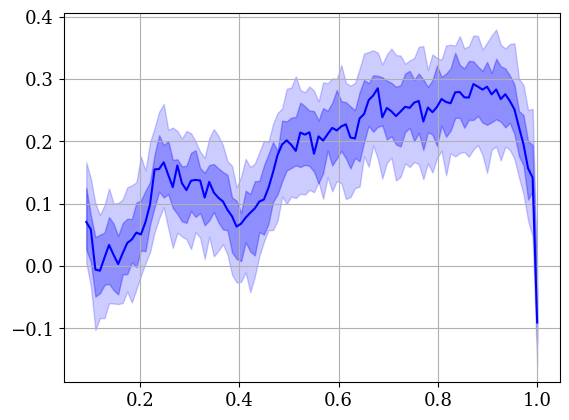

In [5]:
fig, axs = plt.subplots(1, 1)
p10, p25, p50, p75, p90 = datutils.get_percs(
    mah_gap_dict, param='3d', history='M/M0')
# axs[0].set_title('m(a) correlations')
axs.plot(aexp, p50, color='blue')
axs.fill_between(aexp, p10, p90, color='blue', alpha=0.2)
axs.fill_between(aexp, p25, p75, color='blue', alpha=0.3)
axs.grid()

In [6]:
m14 = pd.read_csv('data/mag_diff_GadgetX_3k.csv')
m14.set_index('ID', inplace=True)
m14 = m14[m14['3d'] > 1.25] # select more relaxed clusters
# m14 = m14[m14['proj_x'] > 1.25]
# m14 = m14[m14['proj_y'] > 1.25]
# m14 = m14[m14['proj_z'] > 1.25]

mah_gap_dict, filtered_z_list = datutils.prepare_ma_corrs(
    mah_dict, m14)
z_array = np.array(filtered_z_list)
aexp = 1/(1+z_array)

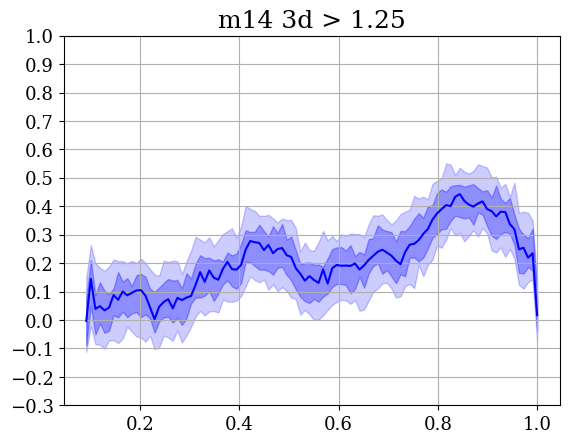

In [7]:
fig, axs = plt.subplots(1, 1)
p10, p25, p50, p75, p90 = datutils.get_percs(
    mah_gap_dict, param='3d', history='M/M0')
# axs[0].set_title('m(a) correlations')
axs.plot(aexp, p50, color='blue')
axs.fill_between(aexp, p10, p90, color='blue', alpha=0.2)
axs.fill_between(aexp, p25, p75, color='blue', alpha=0.3)
axs.set_yticks(np.arange(-0.3, 1.1, 0.1))
axs.set_title('m14 3d > 1.25')
axs.grid()

In [8]:
m14

,3d,proj_x,proj_y,proj_z
ID,,,,
4,1.631226,1.631226,1.631226,1.631226
6,1.964148,1.964148,1.964148,1.964148
10,2.324877,2.324877,2.324877,2.324877
16,1.512516,1.512516,1.512516,1.512516
17,1.784317,0.387047,1.784317,0.387047
...,...,...,...,...
320,3.705206,3.705206,3.705206,3.705206
321,1.295134,1.295134,1.295134,1.295134
322,1.950024,1.950024,1.950024,1.950024


In [9]:
mahz0_df = datutils.ma_zbin(0.0, mah_dict)
med_mass = mahz0_df['mass'].median()
low_mass_ids = mahz0_df.loc[mahz0_df['mass'] < med_mass].index
high_mass_ids = mahz0_df.loc[mahz0_df['mass'] > med_mass].index

In [10]:
m14 = pd.read_csv('data/mag_diff_GadgetX_3k.csv')
# m14 = m14.loc[low_mass_ids]  # select the low or high mass clusters
m14.set_index('ID', inplace=True)

m14 = m14[m14['3d'] > 1.25]  # select more relaxed clusters
mah_gap_dict, filtered_z_list = datutils.prepare_ma_corrs(
    mah_dict, m14)
z_array = np.array(filtered_z_list)
aexp = 1/(1+z_array)

In [11]:
m14

,3d,proj_x,proj_y,proj_z
ID,,,,
4,1.631226,1.631226,1.631226,1.631226
6,1.964148,1.964148,1.964148,1.964148
10,2.324877,2.324877,2.324877,2.324877
16,1.512516,1.512516,1.512516,1.512516
17,1.784317,0.387047,1.784317,0.387047
...,...,...,...,...
320,3.705206,3.705206,3.705206,3.705206
321,1.295134,1.295134,1.295134,1.295134
322,1.950024,1.950024,1.950024,1.950024


In [12]:
for df in mah_gap_dict.values():
    df['m14/logm'] = df['3d'] / np.log10(df['mass'])

/Users/kabelo/anaconda3/envs/cluster_morph/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kabelo/anaconda3/envs/cluster_morph/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kabelo/anaconda3/envs/cluster_morph/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kabelo/anaconda3/envs/cluster_morph/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/kabelo/anaconda3/envs/cluster_morph/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufun

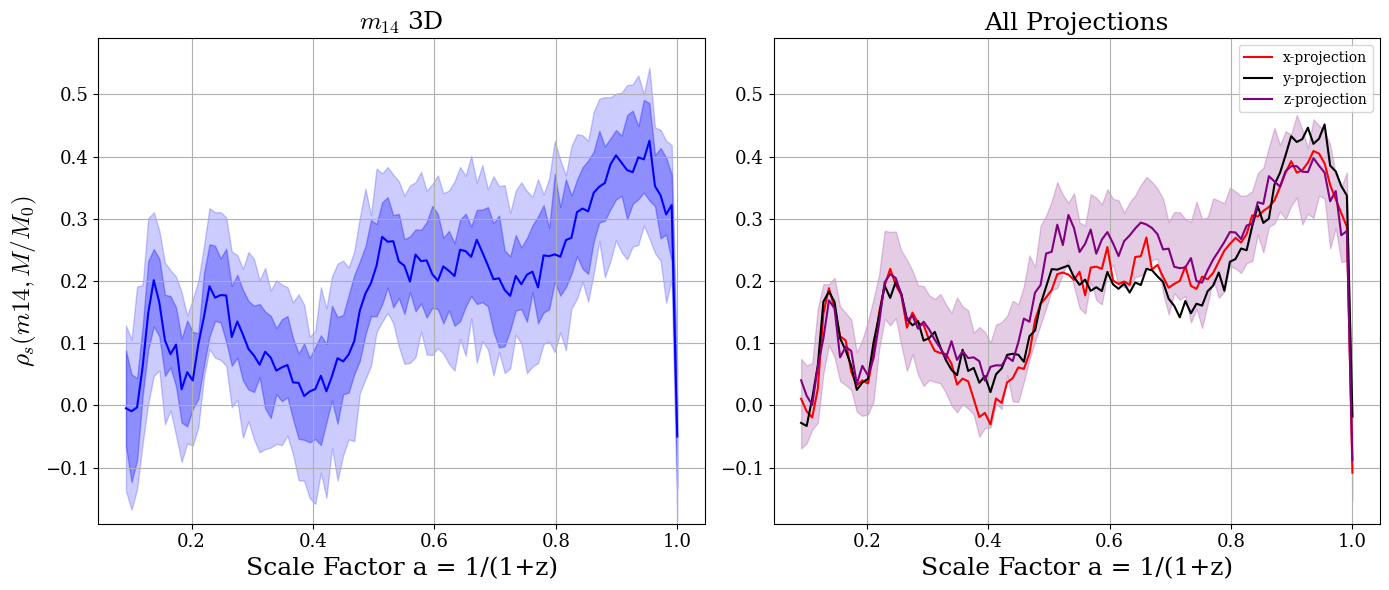

In [18]:
yticks = np.arange(-0.1, 0.6, 0.1)
ylim = (-0.19, 0.59)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

p10 = datutils.get_perc(mah_gap_dict, param='3d', q=10)
p25 = datutils.get_perc(mah_gap_dict, param='3d', q=25)
p50 = datutils.get_perc(mah_gap_dict, param='3d', q=50)
p75 = datutils.get_perc(mah_gap_dict, param='3d', q=75)
p90 = datutils.get_perc(mah_gap_dict, param='3d', q=90)

axs[0].set_title(r'$m_{14}$ 3D', fontsize=18)
axs[0].plot(aexp, p50, color='b')
axs[0].fill_between(aexp, p10, p90, color='b', alpha=0.2)
axs[0].fill_between(aexp, p25, p75, color='b', alpha=0.3)
axs[0].set_xlabel('Scale Factor a = 1/(1+z)')
axs[0].set_ylabel(r'$\rho_s (m14, M/M_0)$')
axs[0].set_yticks(yticks)
axs[0].set_ylim(ylim)
axs[0].grid()

p10 = datutils.get_perc(mah_gap_dict, param='proj_x', q=10)
p25 = datutils.get_perc(mah_gap_dict, param='proj_x', q=25)
p50 = datutils.get_perc(mah_gap_dict, param='proj_x', q=50)
p75 = datutils.get_perc(mah_gap_dict, param='proj_x', q=75)
p90 = datutils.get_perc(mah_gap_dict, param='proj_x', q=90)

axs[1].plot(aexp, p50, color='r', label='x-projection')
# axs[1].fill_between(aexp, p25, p75, color='r', alpha=0.3)

p10 = datutils.get_perc(mah_gap_dict, param='proj_y', q=10)
p25 = datutils.get_perc(mah_gap_dict, param='proj_y', q=25)
p50 = datutils.get_perc(mah_gap_dict, param='proj_y', q=50)
p75 = datutils.get_perc(mah_gap_dict, param='proj_y', q=75)
p90 = datutils.get_perc(mah_gap_dict, param='proj_y', q=90)

axs[1].plot(aexp, p50, color='k', label='y-projection')
# axs[1].fill_between(aexp, p25, p75, color='k', alpha=0.3)

p10 = datutils.get_perc(mah_gap_dict, param='proj_z', q=10)
p25 = datutils.get_perc(mah_gap_dict, param='proj_z', q=25)
p50 = datutils.get_perc(mah_gap_dict, param='proj_z', q=50)
p75 = datutils.get_perc(mah_gap_dict, param='proj_z', q=75)
p90 = datutils.get_perc(mah_gap_dict, param='proj_z', q=90)

axs[1].set_title('All Projections', fontsize=18)
axs[1].plot(aexp, p50, color='purple', label='z-projection')
axs[1].fill_between(aexp, p25, p75, color='purple', alpha=0.2)
axs[1].set_xlabel('Scale Factor a = 1/(1+z)')
axs[1].set_yticks(yticks)
axs[1].set_ylim(ylim)
axs[1].grid()
axs[1].legend()
plt.tight_layout()
plt.savefig('plots/mag_gap_corrs.pdf')
plt.show()

In [3]:
smdf = futils.get_morphologies('results/zx/rin50.0kpc_rout1.0Mpc_205.csv')
dsdf = futils.get_ds()
smdf.drop(columns=['xc_centroid', 'yc_centroid', 'ellipticity_asymmetry',
                    'ellipticity_centroid', 'elongation_asymmetry', 'elongation_centroid',
                    'orientation_centroid', 'xc_asymmetry', 'yc_asymmetry',
                    'orientation_asymmetry', 'rpetro_circ', 'rpetro_ellip',
                    'r20', 'r50', 'r80', 'F(G, M20)',
                    'S(G, M20)', 'sersic_n', 'sersic_xc', 'sersic_yc',
                    'sersic_ellip', 'sersic_theta', 'sersic_chi2_dof'], inplace=True)
display(m14, smdf, dsdf)

,3d,proj_x,proj_y,proj_z
ID,,,,
1,1.009199,1.009199,1.009199,1.009199
2,0.095047,0.095047,0.095047,0.095047
3,1.098583,1.098583,1.098583,1.098583
4,1.631226,1.631226,1.631226,1.631226
5,0.068340,0.068340,0.068340,0.068340
...,...,...,...,...
320,3.705206,3.705206,3.705206,3.705206
321,1.295134,1.295134,1.295134,1.295134
322,1.950024,1.950024,1.950024,1.950024


,rhalf_circ,rhalf_ellip,Gini,M20,C,A,S,sersic_amplitude,sersic_rhalf
ID,,,,,,,,,
1,416.039545,468.726112,0.738113,-0.695323,4.187232,1.132922,0.476770,1.140629e+08,92.742669
2,339.679705,392.604867,0.781684,-0.731242,3.502257,1.226006,0.553680,6.853725e+09,5.916374
3,395.094076,423.652296,0.663512,-0.824733,3.521605,1.341642,0.577852,3.844458e+06,781.999615
4,220.796543,232.489740,0.708796,-0.926278,2.501799,1.162773,0.431288,2.468366e+09,9.022464
5,575.768504,581.951235,0.819537,-0.736250,5.187542,1.303050,0.392266,1.050853e+09,16.184871
...,...,...,...,...,...,...,...,...,...
318,331.086396,382.061807,0.850378,-0.639288,4.058099,1.281493,0.382878,9.754015e+05,21.578794
319,152.247014,185.715371,0.765757,-1.127695,1.703094,0.875258,0.335392,8.479962e+07,117.188655
320,114.381543,127.364005,0.766386,-2.125678,4.348090,0.634346,0.237108,1.227012e+08,88.186358


,eta_200[3],delta_200[4],fm_200[5],fm2_200[6],eta_500[8],delta_500[9],fm_500[10],fm2_500[11]
ID,,,,,,,,
1,1.113784,0.120344,0.191074,0.057627,0.988455,0.125954,1.902216e+09,8.830347e+08
2,1.072935,0.040830,0.112020,0.036127,1.113930,0.038203,7.964150e+08,1.933066e+08
3,0.989234,0.172955,0.328392,0.214298,1.187227,0.047095,1.121146e+09,1.948033e+08
4,1.121951,0.187624,0.219985,0.059437,1.047104,0.165363,1.913957e+09,9.464093e+08
5,1.686966,0.185922,0.231555,0.109159,1.577747,0.254876,2.472550e+09,1.322065e+09
...,...,...,...,...,...,...,...,...
320,1.076578,0.022932,0.050779,0.007882,1.095860,0.024954,4.374249e+08,1.027306e+08
321,1.177087,0.112965,0.142317,0.074800,1.157092,0.136708,1.606108e+09,1.014180e+09
322,1.080186,0.057003,0.109420,0.016268,1.212501,0.047377,7.536417e+08,1.377136e+08


In [4]:
df1 = smdf.join(other=m14, on='ID', how='inner')
df2 = dsdf.join(other=m14, on='ID', how='inner') 

corrs1 = df1.corr(method='spearman')
corrs2 = df2.corr(method='spearman')

In [5]:
display(corrs1['proj_z'][np.abs(corrs1['proj_z']) > 0.2])
display(corrs2['proj_z'][np.abs(corrs2['proj_z']) > 0.2])

3d        0.962540
proj_x    0.939818
proj_y    0.925528
proj_z    1.000000
Name: proj_z, dtype: float64

delta_200[4]   -0.277486
fm_200[5]      -0.330235
fm2_200[6]     -0.264511
delta_500[9]   -0.275406
fm_500[10]     -0.290166
fm2_500[11]    -0.253756
3d              0.967984
proj_x          0.946261
proj_y          0.938762
proj_z          1.000000
Name: proj_z, dtype: float64

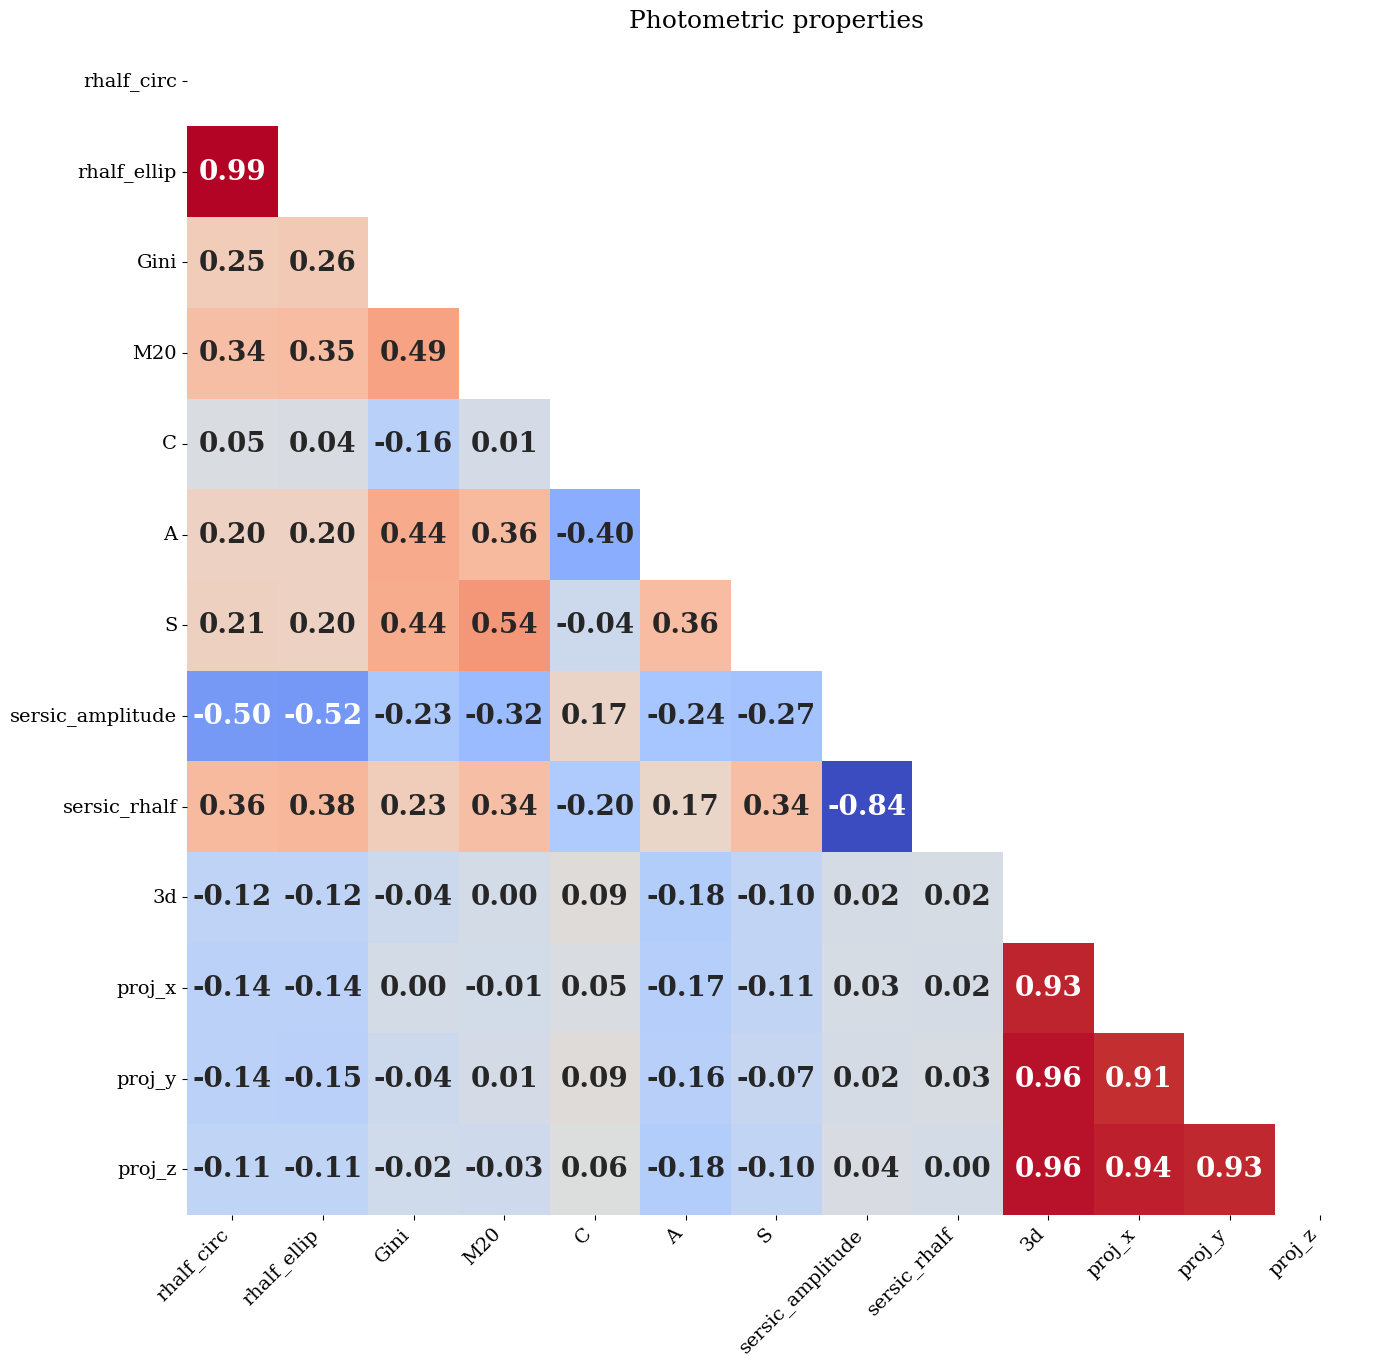

In [7]:
plots.plot_corr_matrix(corrs1, title='Photometric properties',
                       save=True, fname='photo_corrs.pdf', annot=True)

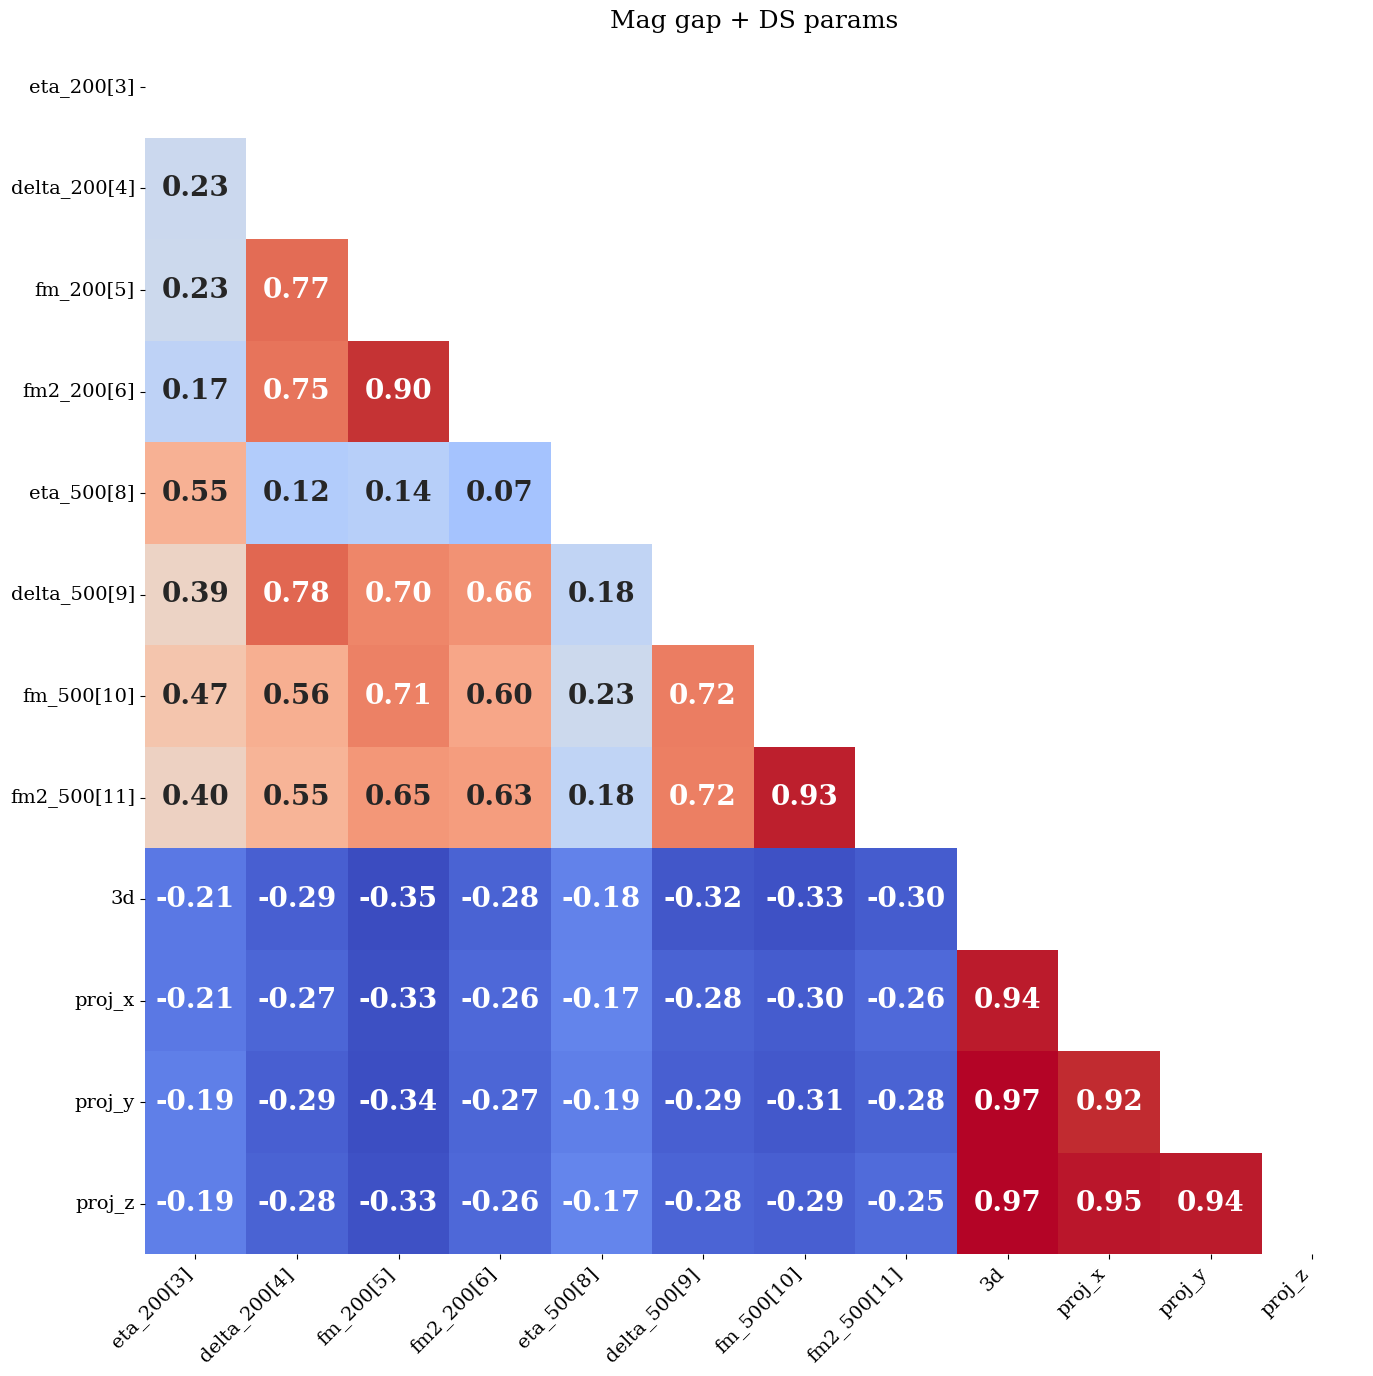

In [9]:
plots.plot_corr_matrix(corrs2, title='Mag gap + DS params',
                       save=True, fname='m14_ds_corrs.pdf', annot=True)